In [2]:
# !pip install tensorflow  ## framework for training deep learning models
# note that tensorflow doesnt support python 3.13 yet. create a new env and use python 3.11 or 3.10.

In [3]:
# !pip install keras

In [6]:
# import sys
# print(sys.executable)
# !{sys.executable} -m pip install matplotlib

In [24]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt
np.random.seed(42)

### Loading the dataset

In [25]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [26]:
print(X_train_full.shape, X_test.shape, y_train_full.shape, y_test.shape)

(60000, 28, 28) (10000, 28, 28) (60000,) (10000,)


In [27]:
set(y_test.tolist())
## 10 unique labels in the dataset

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

### Splitting into train and val

In [28]:
# normalising the pixel values to 0-1, helping the NN to train faster
X_train, X_val = X_train_full[:50000]/255.0 , X_train_full[50000:]/255.0
y_train, y_val = y_train_full[:50000] , y_train_full[50000:]
X_test = X_test/255.0

### Visualising the dataset

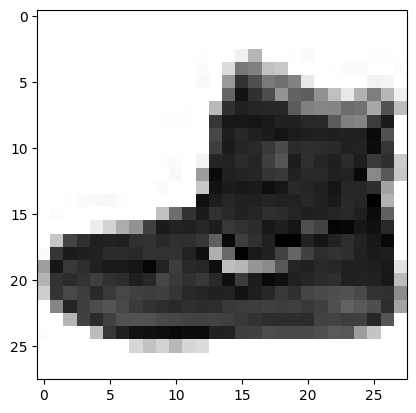

In [29]:
plt.imshow(X_train[0], cmap='binary')
plt.show()

### Customize the Neural Network 
Setup the architecture of the model with model/architecture hyperparameters
1. Sequential Aspect: If we start the model layer by layer like first input, then hidden and then output, then it is called sequential. 
2. Functional Aspect: At certain points, there is a feedback loop as well. \

Sequential API is used to build simple linear neural networks, whereas the Functional API allows building complex models with multiple inputs, outputs, and non-linear connections. The difference is not about performance, it’s about model structure capability.\

Where Sequential is enough: Basic classification, Simple feedforward networks, Straight pipeline (no branching) \
Where Functional is required: CNN with skip connections (ResNet-like), Multi-input models, Multi-task learning

In [30]:
## Hyperparameters: No of layers, neurons inside layers and learning rate

In [31]:
# Let's begin with a sequential NN
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28,28]))  ## input has to be given as a vector, so just use the flatten function
model.add(keras.layers.Dense(300, activation='relu')) # First hidden layer
model.add(keras.layers.Dense(100, activation='relu')) # second hidden layer
model.add(keras.layers.Dense(10, activation='softmax')) # output layer  ## if classification, use sigmoid for binary and softmax for multiclass

In [32]:
model.summary()
## 28*28 = 784 for input layer
## 784 * 300 + 300 (bias) for 1st layer
## 300 * 100 + 100 (bias) for 2nd layer
## 100 * 10 + 10(bias) for the output layer
## Note that a single bias is added to the neuron with different weights. So, weights are the parameters, not the bias

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 300)                 │         235,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the network
Tells the network how to learn by adding Training hyperparameters. ML models have some of this step inbuilt and some are added while declaring an instance of the model, and thus, dont require these Training hyperparameters. \
Loss is what model minimizes to learn, metrics is what we use for evaluation of the model. Metrics are intuitive for humans, while loss is not intuitive. Metrics aren't used for training, just for showing the model performance

In [33]:
# There are several arguments that are used in compilation. 
# You can also add learning rate here, by default, the learning parameter will depend on the choice of the optimizer
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)
# if you use mini batch gradient descent or ada gradient descent, you need to give batch size, and that batch size will be put during training call.

### Fitting the model
1. Validation Data: Note that we put validation data, which is of no use here as we dont tune hyperparameters. So, what is the need of validation data? Validation is commonly used to callback the network from training more epochs as we see the loss reduction is saturated. We as the architect and master of the hyperparameters tune the model according to this data. Therefore it indirectly influences your model because it directly influences your design decisions.
2. Why Test Data: So, if you callback your model, then it is indirectly influenced by it. So, we need to see it's performance on an entirely unseen dataset.


In [40]:
# Epoch is another hyperparameter, and high epoch leads to overfitting, while low epoch leads to underfitting
history = model.fit(X_train, y_train, epochs = 10, validation_data = (X_val, y_val))
# you can also put validation_split = 0.1 instead of keeping a validation data separate from above

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9197 - loss: 0.2255 - val_accuracy: 0.8866 - val_loss: 0.3192
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9221 - loss: 0.2214 - val_accuracy: 0.8901 - val_loss: 0.3106
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9227 - loss: 0.2179 - val_accuracy: 0.8874 - val_loss: 0.3197
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9230 - loss: 0.2141 - val_accuracy: 0.8827 - val_loss: 0.3281
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9235 - loss: 0.2115 - val_accuracy: 0.8666 - val_loss: 0.3887
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9260 - loss: 0.2081 - val_accuracy: 0.8859 - val_loss: 0.3203
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9273 - loss: 0.2041 - val_accuracy: 0.8906 - val_loss: 0.3150
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9285 - loss: 0

<Axes: >

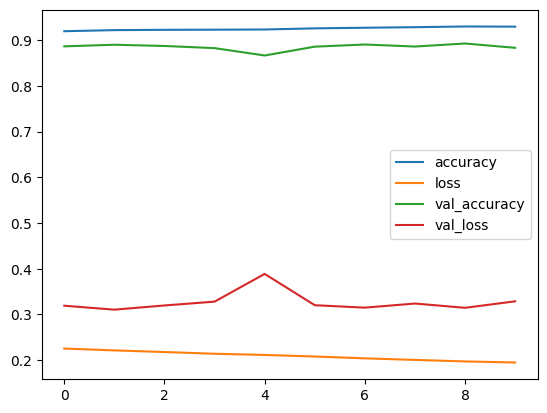

In [41]:
# Plotting the evaluation vectors
evals = pd.DataFrame(history.history)
evals.plot()

In [42]:
model.evaluate(X_test, y_test)
## Loss, Accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8790 - loss: 0.3475


[0.34746628999710083, 0.8790000081062317]